#  Previsão de Preço de Veículos Usados no Brasil

> ⚠️ **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

---

## Metodologia: CRISP-DM

| Fase | Descrição |
|---|---|
| 1️⃣ Entendimento do Negócio | Prever o valor de venda de veículos usados no Brasil |
| 2️⃣ Entendimento dos Dados | Análise Exploratória (EDA) |
| 3️⃣ Preparação dos Dados | Limpeza, imputação, feature engineering, encoding |
| 4️⃣ Modelagem | Comparação de 7 algoritmos de regressão |
| 5️⃣ Avaliação | Métricas |
| 6️⃣ Implantação | Deploy no Streamlit.io |

**Dataset:** 10.000 registros de veículos usados  
**Variável alvo:** `Valor_Venda` (R$)

### Insights da EDA

| # | Insight |
|---|---|
| 1 | A distribuição de `Valor_Venda` é **fortemente assimétrica à direita** — há outliers acima de R$500k |
| 2 | Após transformação log, a distribuição se aproxima de uma normal |
| 3 | Veículos mais novos (pós-2015) valem consideravelmente mais |
| 4 | Câmbio **automático** tem mediana de preço maior que manual |
| 5 | A correlação entre `Quilometragem` e `Valor_Venda` é **negativa** |
| 6 | `Ano` tem 100 valores nulos (1%) → imputação com mediana |
| 7 | Marcas premium (Jeep, Toyota) têm valores medianos mais altos |
| 8 | Carros com 23 e 20 anos são muitos vendidos, provavelmente o valor e a isenção de imposto de circulação |
| 9 | Não foi observada nenhuma influência no valor de venda os seguintes items: Cambio', 'Combustivel', 'Cor', 'Portas. Praticamente valores iguais|
| 10 | Se comprovou que a relação idade do carro e valor de vemda é inversamente proporcional. Quanto maior a idade do carro menor o valor de venda |
| 11 | Top 3 marcas que menos se desvalorizam com a idade do carro: Jeep, Toyota e Honda, nessa ordem |
| 12 | Top 3 marcas que mais se desvalorizam com a idade do carro: Renault, Fiat e Volkswagem |



### Instalar libs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


### Leitura do dataset

In [ ]:
# Carregar dataset
# Ajuste o caminho conforme necessário
DATA_PATH = '/content/dataset_carros_brasil.csv'

df = pd.read_csv(DATA_PATH)

print('=' * 60)
print('VISÃO GERAL DO DATASET')
print('=' * 60)
print(f'Linhas:   {df.shape[0]:,}')
print(f'Colunas:  {df.shape[1]}')

df.head()

VISÃO GERAL DO DATASET
Linhas:   10,000
Colunas:  9


,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda
0,Ford,EcoSport,2003.0,82624,Azul,Automático,Flex,4,52604.2
1,Hyundai,HB20S,2017.0,69260,Azul,Automático,Diesel,2,63219.0
2,Jeep,Renegade,2008.0,106493,Cinza,Manual,Gasolina,2,79710.4
3,Toyota,Corolla,2018.0,53570,Prata,Automático,Flex,2,99149.0
4,Ford,Ranger,2009.0,21643,Prata,Manual,Flex,2,68913.4


### Tipo dos dados

In [ ]:
# Tipos de dados e valores nulos
info = pd.DataFrame({
    'Tipo'     : df.dtypes,
    'Nulos'    : df.isnull().sum(),
    '% Nulos'  : (df.isnull().mean() * 100).round(2),
    'Únicos'   : df.nunique(),
})
print('\n--- Tipos, Nulos e Cardinalidade ---')
display(info)


--- Tipos, Nulos e Cardinalidade ---


,Tipo,Nulos,% Nulos,Únicos
Marca,object,0,0.0,10
Modelo,object,0,0.0,32
Ano,float64,100,1.0,24
Quilometragem,object,0,0.0,9653
Cor,object,0,0.0,6
Cambio,object,0,0.0,2
Combustivel,object,0,0.0,3
Portas,int64,0,0.0,2
Valor_Venda,float64,0,0.0,9672


### Estatistica Descritiva

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ano,9900.0,2011.516061,6.903872,2000.0,2006.00,2012.0,2017.0,2023.0
Portas,10000.0,3.008600,1.000013,2.0,2.00,4.0,4.0,4.0
Valor_Venda,10000.0,83097.486840,166858.222134,10000.0,44467.05,58905.7,74804.4,1241962.0


### Checar dados ausentes
- Ano: 100 registros nulos

In [ ]:
df.isna().sum()

,0
Marca,0
Modelo,0
Ano,100
Quilometragem,0
Cor,0
Cambio,0
Combustivel,0
Portas,0
Valor_Venda,0


### Identificar o ano mais frequente na base de dados.
### Preencher os campos sem dados com esta informação.

In [ ]:
mode_ano = df['Ano'].mode()[0]
print("Ano mais frequente:", mode_ano)
df['Ano'].fillna(mode_ano, inplace=True)
print("Usado para preencher os valores ausentes.")

Ano mais frequente: 2015.0
Usado para preencher os valores ausentes.


### Checar o tipo dos dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          10000 non-null  object 
 1   Modelo         10000 non-null  object 
 2   Ano            10000 non-null  float64
 3   Quilometragem  10000 non-null  object 
 4   Cor            10000 non-null  object 
 5   Cambio         10000 non-null  object 
 6   Combustivel    10000 non-null  object 
 7   Portas         10000 non-null  int64  
 8   Valor_Venda    10000 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 703.3+ KB


### Converter o valor de Ano para inteiro.

In [ ]:
df['Ano'] = df['Ano'].astype(int)

### Checar os valores em Quilometragem.
### Identificado 100 registros com a string 'erro_medicao'

In [ ]:
df['Quilometragem'].value_counts()

,count
Quilometragem,
erro_medicao,100
166373,3
124790,3
97491,3
118222,3
...,...
10301,1
124798,1
186073,1


### Existem 100 registros identificados como 'erro_medicao'.
### Estas linhas serão removidas.

In [ ]:
df['Quilometragem'] = df['Quilometragem'].replace('erro_medicao', np.nan)
df['Quilometragem'] = pd.to_numeric(df['Quilometragem'])
df = df.dropna(subset=['Quilometragem'])

In [ ]:
df.shape

(9900, 9)

In [ ]:
df['Quilometragem'].value_counts()

,count
Quilometragem,
645.0,3
97491.0,3
118222.0,3
124790.0,3
166373.0,3
...,...
10301.0,1
124798.0,1
186073.0,1


### Converter para inteiro.

In [ ]:
df['Quilometragem'] = df['Quilometragem'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9900 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          9900 non-null   object 
 1   Modelo         9900 non-null   object 
 2   Ano            9900 non-null   int64  
 3   Quilometragem  9900 non-null   int64  
 4   Cor            9900 non-null   object 
 5   Cambio         9900 non-null   object 
 6   Combustivel    9900 non-null   object 
 7   Portas         9900 non-null   int64  
 8   Valor_Venda    9900 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 773.4+ KB


In [ ]:
# Calcula os limites do IQR
def remove_outliers(df, col):
    print(f'\nChecar outliers de {col}')
    print('Antes:', df.shape)
    Q1 = df[col].quantile(0.25) #calcula o quartil de 25% (valor abaixo do qual estão 25% dos dados ordenados)
    Q3 = df[col].quantile(0.75) #calcula o quartil de 75% (valor abaixo do qual estão 75% dos dados ordenados)
    IQR = Q3 - Q1 #calcula o índice interquartil

    limite_inferior = Q1 - 1.5 * IQR #calcula o o limite inferior
    limite_superior = Q3 + 1.5 * IQR #calcula o o limite superior
    df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]
    print('Depois:', df.shape)
    return df

### Identificar colunas numéricas.

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Valor_Venda')
numeric_features

Index(['Ano', 'Quilometragem', 'Portas'], dtype='object')

### Remover outliers das variáveis numéricas (Ano, Quilometragem, Portas)

In [ ]:
for col in numeric_features:
    df = remove_outliers(df, col)
print("-"* 10)
# Exibir as informações do DataFrame após a remoção de outliers para verificar o novo shape e tipos de dados
df.info()


Checar outliers de Ano
Antes: (9900, 9)
Depois: (9900, 9)

Checar outliers de Quilometragem
Antes: (9900, 9)
Depois: (9900, 9)

Checar outliers de Portas
Antes: (9900, 9)
Depois: (9900, 9)
----------
<class 'pandas.core.frame.DataFrame'>
Index: 9900 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          9900 non-null   object 
 1   Modelo         9900 non-null   object 
 2   Ano            9900 non-null   int64  
 3   Quilometragem  9900 non-null   int64  
 4   Cor            9900 non-null   object 
 5   Cambio         9900 non-null   object 
 6   Combustivel    9900 non-null   object 
 7   Portas         9900 non-null   int64  
 8   Valor_Venda    9900 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 773.4+ KB


### Visualizar a distribuição das demais variáveis numéricas.


Visualizando distribuição para a coluna: Ano



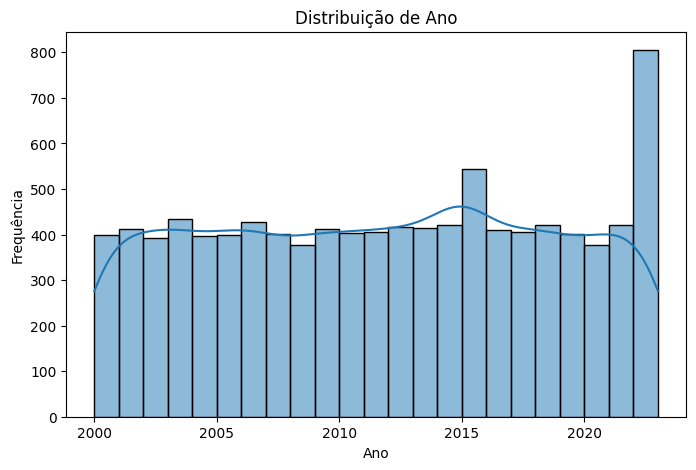

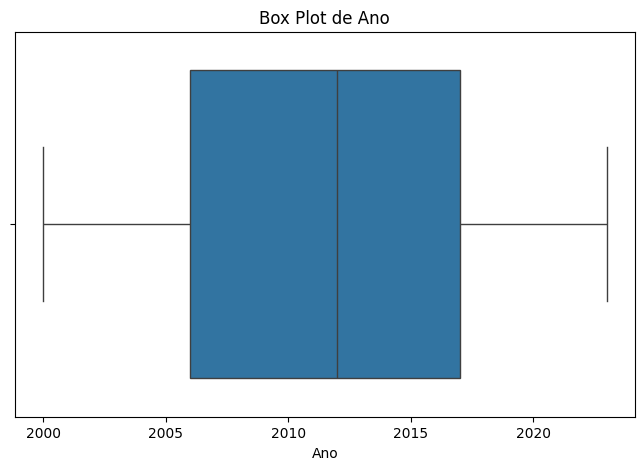


Visualizando distribuição para a coluna: Quilometragem



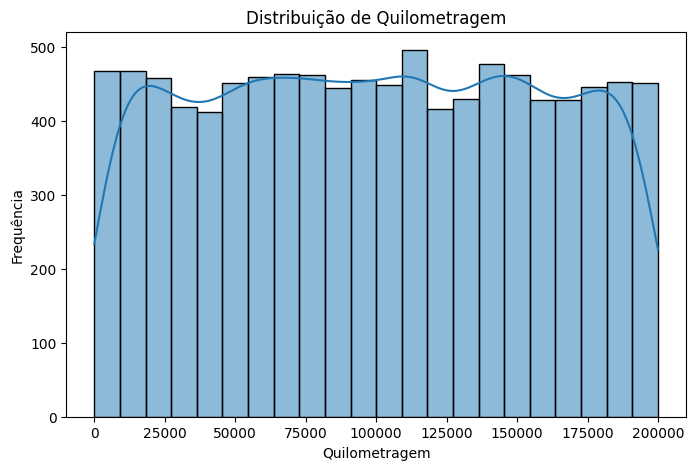

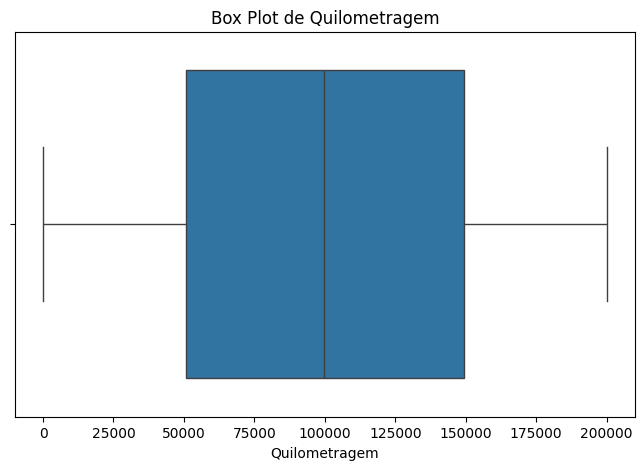


Visualizando distribuição para a coluna: Portas



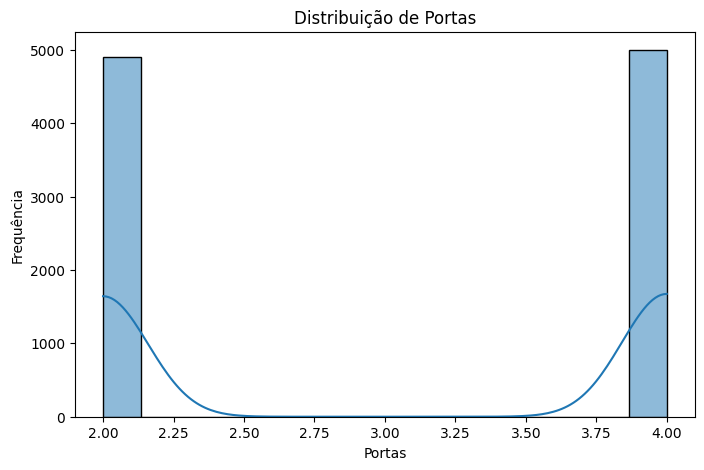

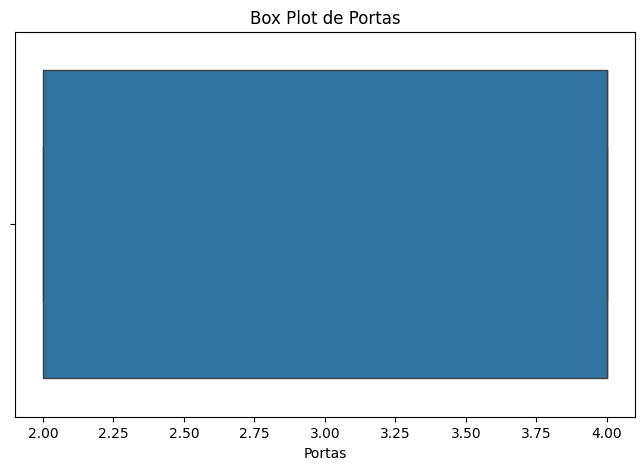

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Valor_Venda')

for col in numeric_features:
    print(f'\nVisualizando distribuição para a coluna: {col}\n')
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.savefig(f'/content/imgs/Distribuicao_{col}.png')
    plt.show()
    print(" ")

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot de {col}')
    plt.xlabel(col)
    plt.savefig(f'/content/imgs/Boxplot_{col}.png')
    plt.show()

### Distribuição da variável alvo - Valor de Venda

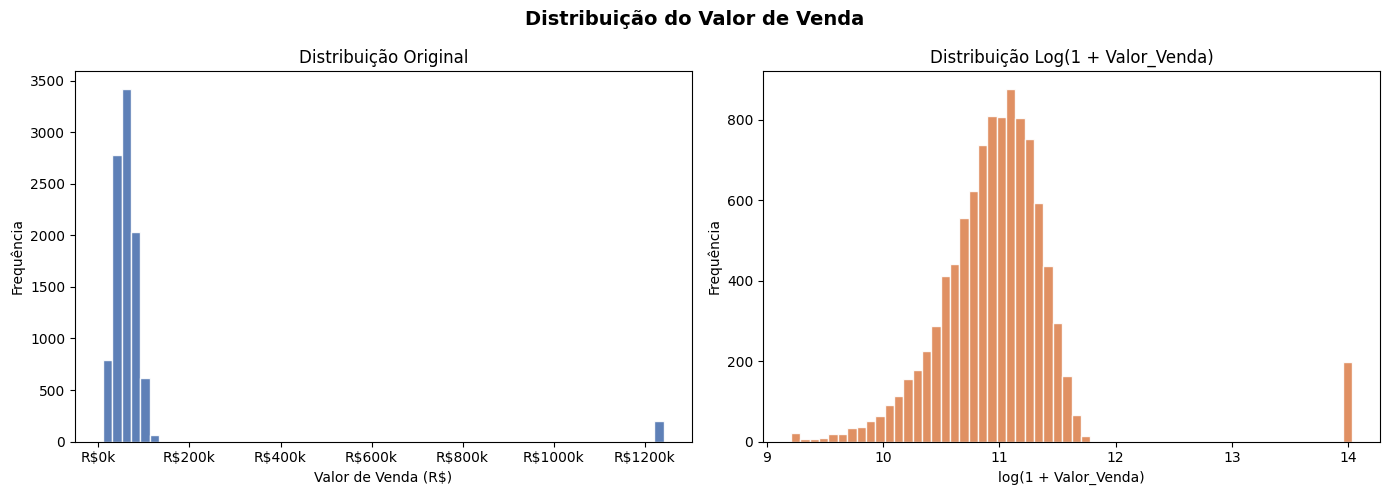

In [ ]:
# ── Gráfico 1: Distribuição da variável alvo ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição do Valor de Venda', fontsize=14, fontweight='bold')

axes[0].hist(df['Valor_Venda'], bins=60, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].set_title('Distribuição Original')
axes[0].set_xlabel('Valor de Venda (R$)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))

log_vals = np.log1p(df['Valor_Venda'])
axes[1].hist(log_vals, bins=60, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].set_title('Distribuição Log(1 + Valor_Venda)')
axes[1].set_xlabel('log(1 + Valor_Venda)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('/content/imgs/distribuicao_alvo.png')
plt.show()

### Remover outliers da variável alvo `Valor_Venda`

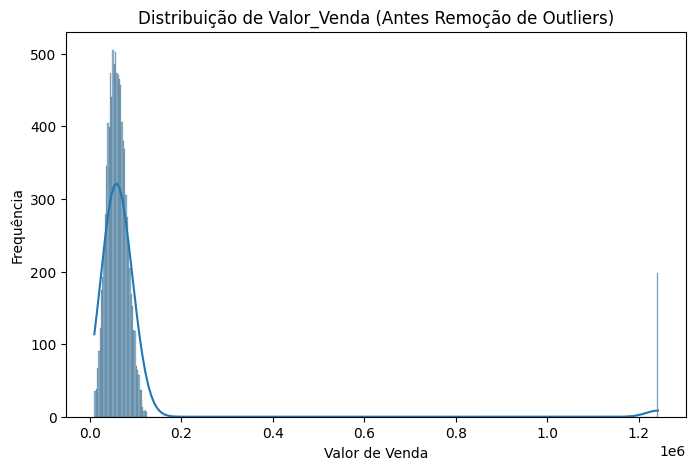

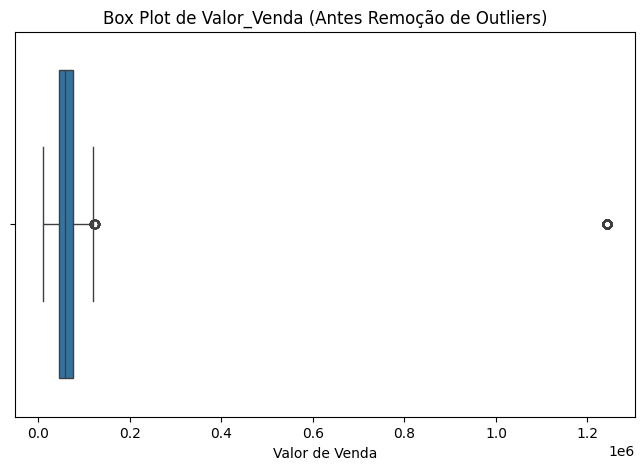

In [ ]:

# Visualize a distribuição antes da  remoção de outliers
plt.figure(figsize=(8, 5))
sns.histplot(df['Valor_Venda'], kde=True)
plt.title('Distribuição de Valor_Venda (Antes Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.ylabel('Frequência')
plt.savefig(f'/content/imgs/Distribuicao_Valor_venda_com_outliers.png')
plt.show()

print (' ')
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Valor_Venda'])
plt.title('Box Plot de Valor_Venda (Antes Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.savefig(f'/content/imgs/Boxplot_Valor_venda_com_outliers.png')
plt.show()


Checar outliers de Valor_Venda
Antes: (9900, 9)
Depois: (9686, 9)


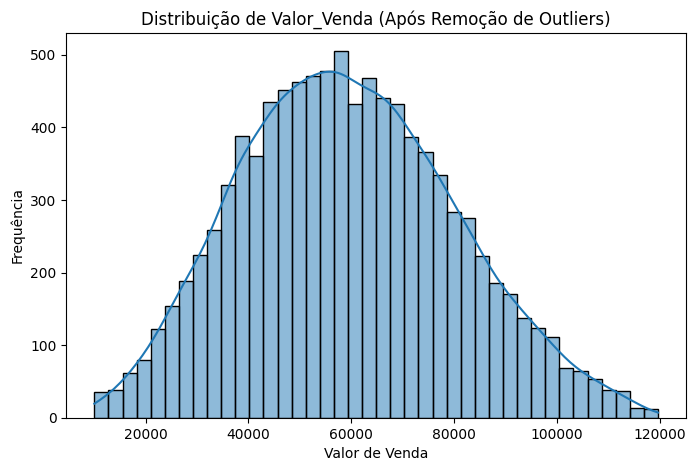

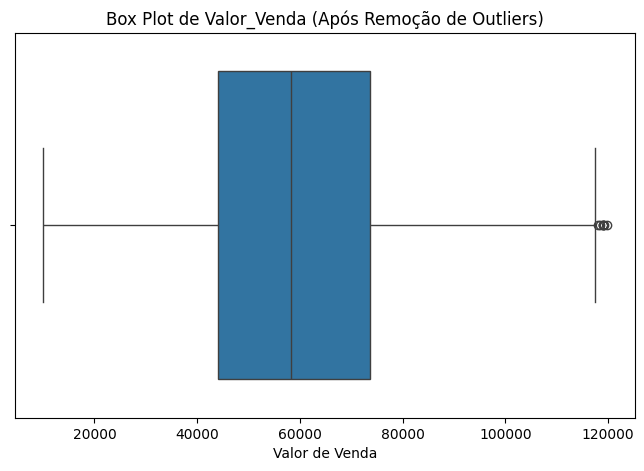

In [ ]:
df = remove_outliers(df, 'Valor_Venda')

# Visualize a distribuição novamente após a remoção de outliers
plt.figure(figsize=(8, 5))
sns.histplot(df['Valor_Venda'], kde=True)
plt.title('Distribuição de Valor_Venda (Após Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.ylabel('Frequência')
plt.savefig(f'Distribuicao_Valor_venda_sem_outliers.png')
plt.show()
print(' ')
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Valor_Venda'])
plt.title('Box Plot de Valor_Venda (Após Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.savefig(f'Boxplot_Valor_venda_sem_outliers.png')
plt.show()

### Matriz de correlação

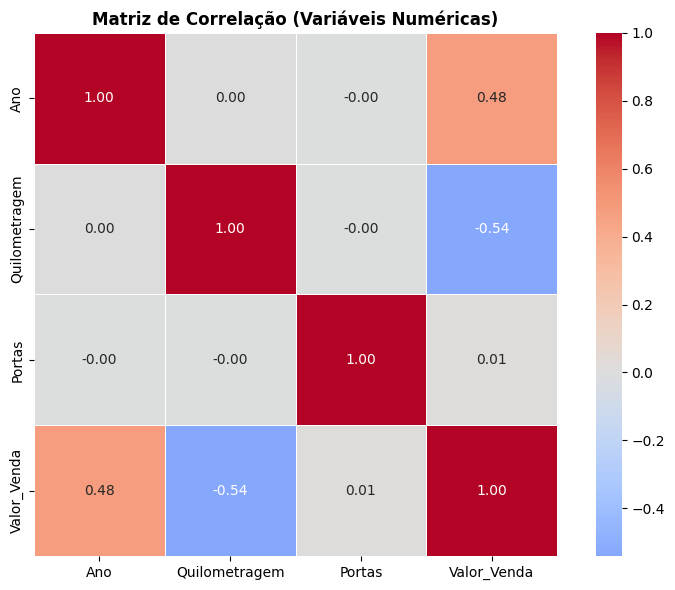

In [ ]:
# ── Gráfico 3: Matriz de Correlação ──────────────────────────────
df_num = df.copy()
df_num['Quilometragem'] = pd.to_numeric(df_num['Quilometragem'], errors='coerce')
num_cols_corr = df_num.select_dtypes(include=np.number).columns.tolist()
corr = df_num[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Matriz de Correlação (Variáveis Numéricas)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/imgs/correlacao.png')
plt.show()

### Mediana do Valor de Venda por Ano de Fabricação

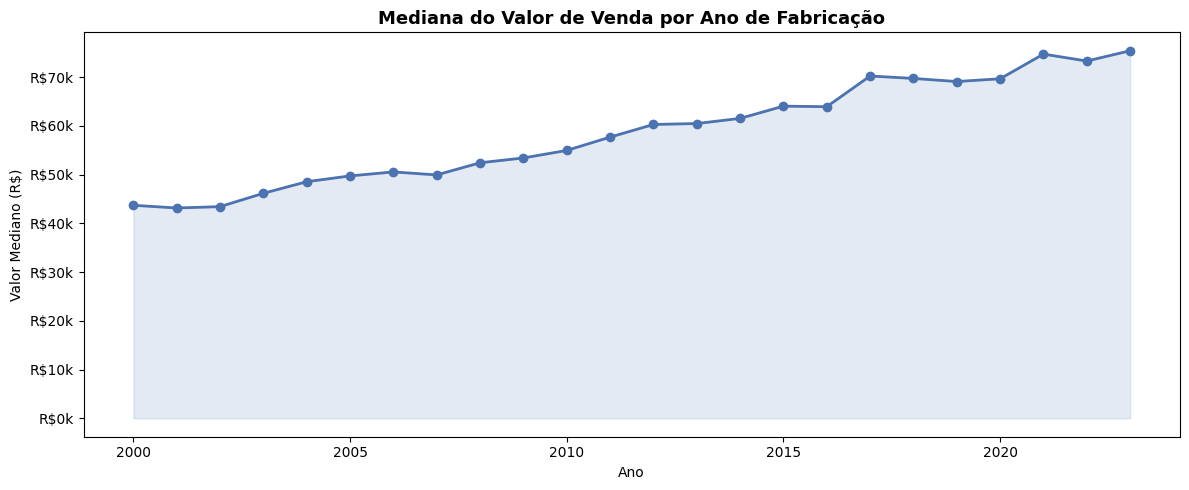

In [ ]:
# ── Gráfico 4: Valor mediano por Ano ─────────────────────────────
df_limpo = df.dropna(subset=['Ano'])
media_ano = df_limpo.groupby('Ano')['Valor_Venda'].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(media_ano['Ano'], media_ano['Valor_Venda'], marker='o', color='#4C72B0', linewidth=2)
ax.fill_between(media_ano['Ano'], media_ano['Valor_Venda'], alpha=0.15, color='#4C72B0')
ax.set_title('Mediana do Valor de Venda por Ano de Fabricação', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Valor Mediano (R$)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('/content/imgs/valor_vs_ano.png')
plt.show()

### Valor de Venda por Variáveis Categoricas

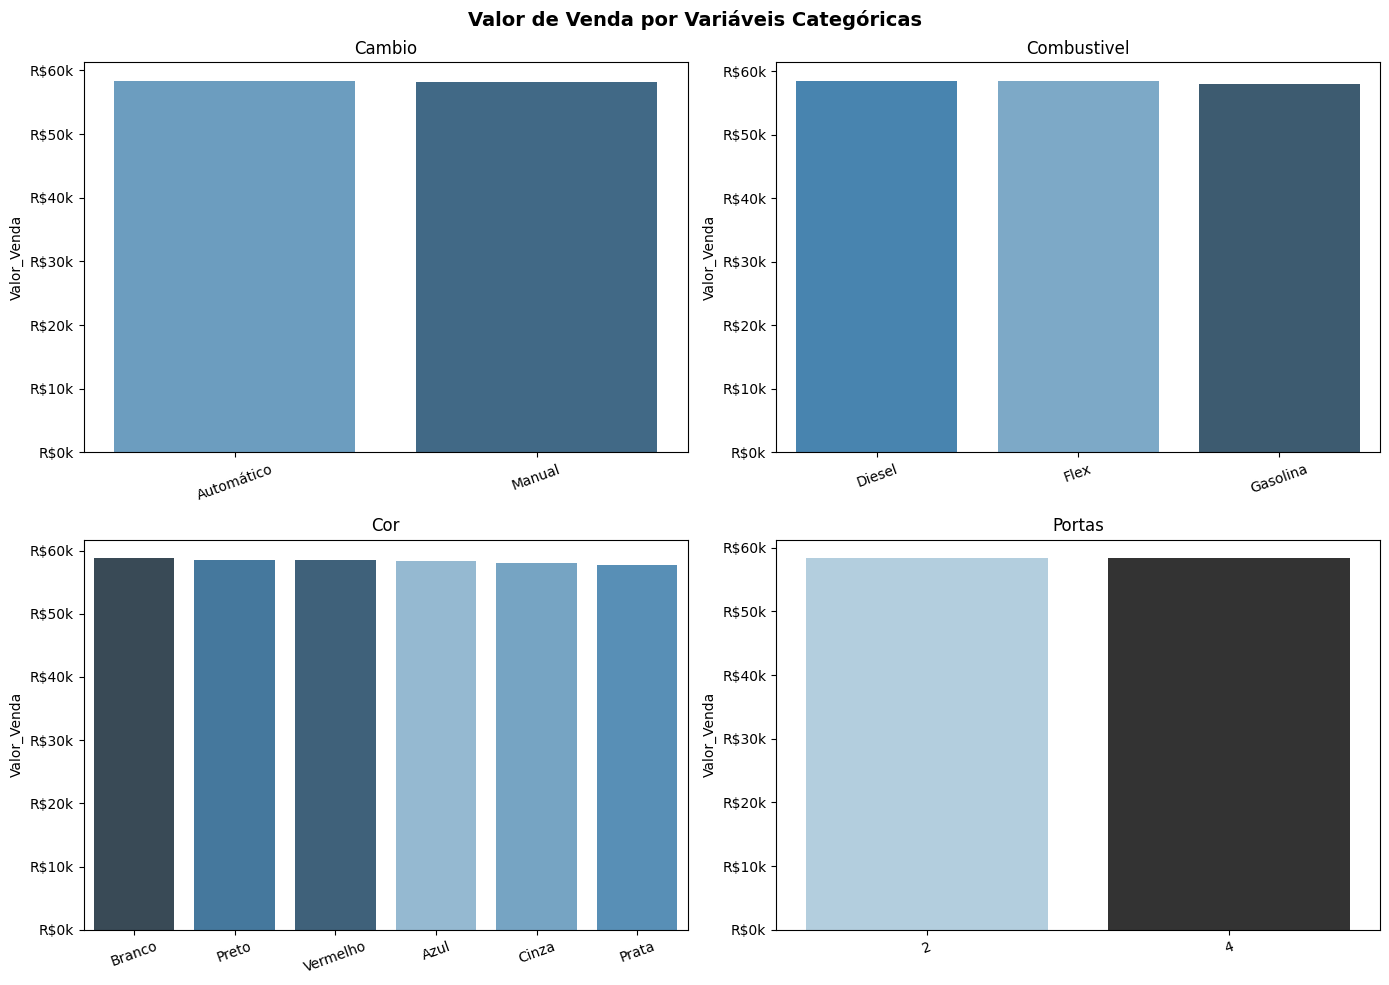

In [ ]:
# ── Gráfico 5: Variáveis Categóricas ─────────────────────────────
cat_plot_cols = ['Cambio', 'Combustivel', 'Cor', 'Portas']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Valor de Venda por Variáveis Categóricas', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_plot_cols):
    ordem = (
        df.groupby(col)['Valor_Venda'].median()
        .sort_values(ascending=False).index
    )
    sns.barplot(data=df, x=col, y='Valor_Venda', order=ordem, ax=ax,
                estimator='median', errorbar=None, hue=col, palette='Blues_d', legend=False)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('/content/imgs/categoricas.png')
plt.show()

### Analisar a distribuição de vendas por marca.

In [ ]:
df['Marca'].value_counts()

,count
Marca,
Volkswagen,1024
Nissan,1002
Honda,996
Ford,990
Renault,960
Fiat,954
Chevrolet,952
Hyundai,944
Toyota,938


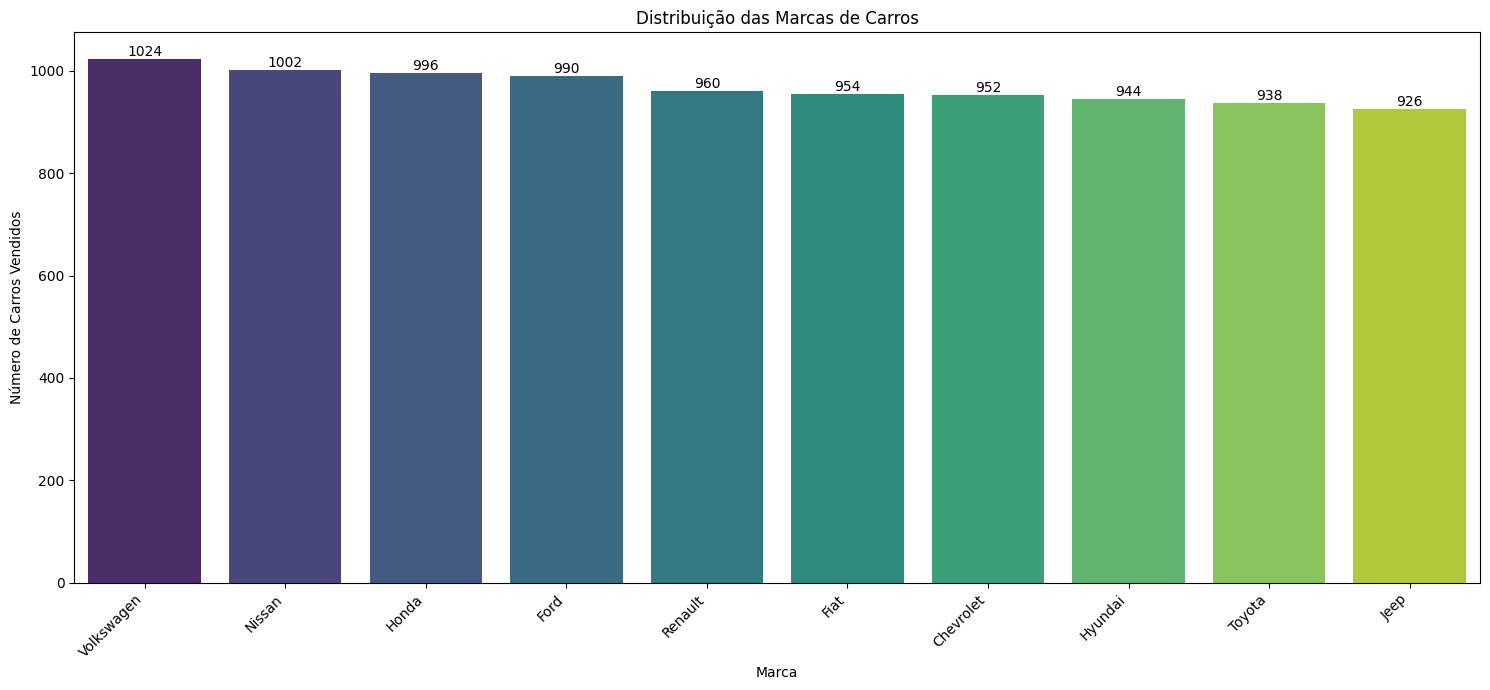

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='Marca', order=df['Marca'].value_counts().index, palette='viridis')
plt.title('Distribuição das Marcas de Carros')
plt.xlabel('Marca')
plt.ylabel('Número de Carros Vendidos')
plt.xticks(rotation=45, ha='right')

# Adicionar os valores acima das barras
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d')

plt.tight_layout()
plt.savefig(f'Distribuicao_marcas.png')
plt.show()

### Analisar a venda de carros por marca e ano.

In [ ]:
cross_tab_data = pd.crosstab(df['Marca'], df['Ano'])
cross_tab_data

Ano,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Marca,,,,,,,,,,,,,,,,,,,,,
Chevrolet,32,44,42,45,35,39,48,40,39,41,...,41,60,42,36,37,29,42,29,44,36
Fiat,43,37,33,42,48,35,35,32,41,49,...,34,45,38,39,43,37,41,40,36,43
Ford,38,58,39,54,31,29,39,46,34,37,...,45,46,47,34,43,43,36,36,44,35
Honda,46,41,36,49,41,45,36,45,48,32,...,43,59,39,43,36,38,30,41,41,38
Hyundai,42,35,39,44,34,39,39,35,37,37,...,44,68,44,31,38,29,41,45,31,40
Jeep,31,44,42,40,43,43,39,34,26,42,...,41,43,31,47,43,49,33,51,37,30
Nissan,41,27,40,42,41,46,49,47,41,35,...,33,51,39,46,40,46,40,44,44,34
Renault,36,35,49,25,39,41,40,42,40,46,...,48,48,40,41,36,34,39,57,41,48
Toyota,39,43,32,42,44,42,43,28,37,36,...,39,61,33,47,40,35,24,26,40,40


###

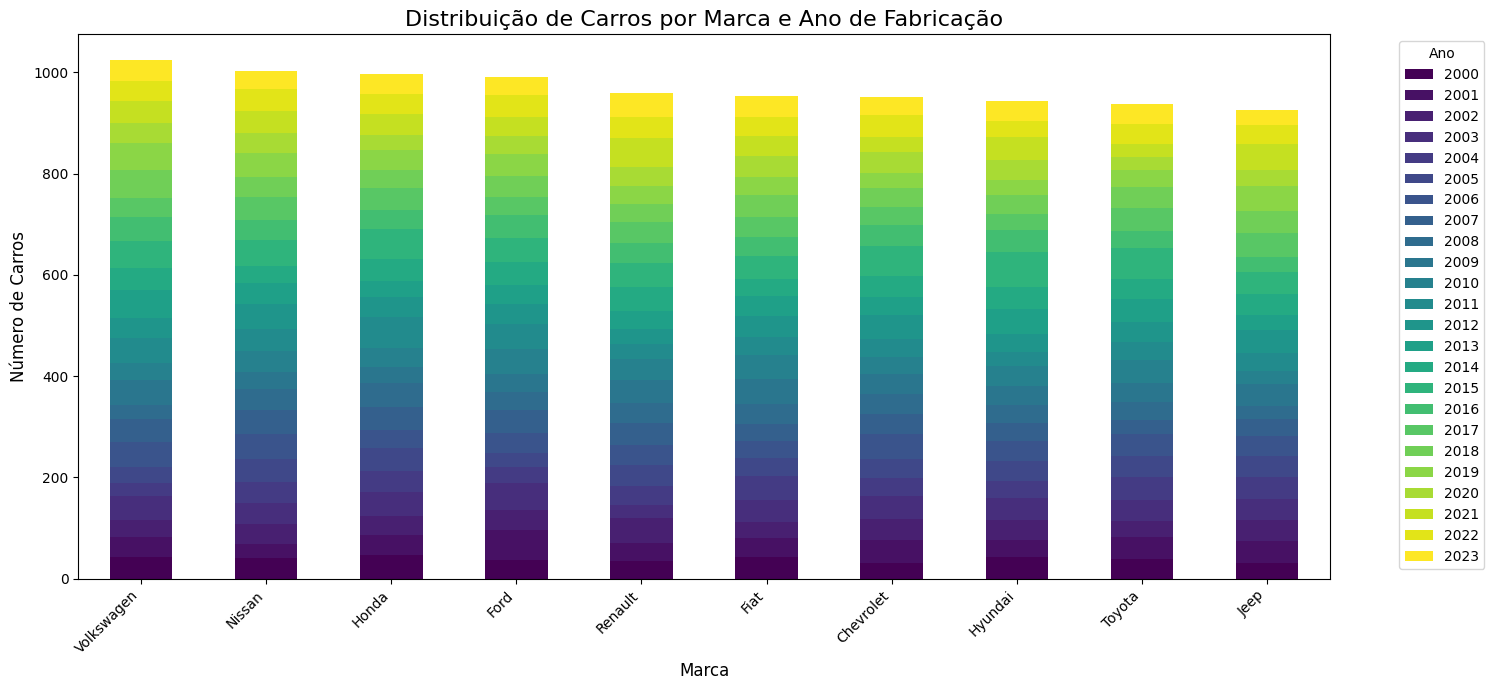

In [ ]:
# Order as marcas pelo total vendido
brand_order = cross_tab_data.sum(axis=1).sort_values(ascending=False).index
cross_tab_data = cross_tab_data.loc[brand_order]

ax = cross_tab_data.plot(kind='bar', stacked=True,figsize=(15, 7), colormap='viridis')

plt.title('Distribuição de Carros por Marca e Ano de Fabricação', fontsize=16)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Número de Carros', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout()
plt.savefig(f'Distribuicao_marcas_ano.png')
plt.show()

In [ ]:
df

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda
0,Ford,EcoSport,2003,82624,Azul,Automático,Flex,4,52604.2
1,Hyundai,HB20S,2017,69260,Azul,Automático,Diesel,2,63219.0
2,Jeep,Renegade,2008,106493,Cinza,Manual,Gasolina,2,79710.4
3,Toyota,Corolla,2018,53570,Prata,Automático,Flex,2,99149.0
4,Ford,Ranger,2009,21643,Prata,Manual,Flex,2,68913.4
...,...,...,...,...,...,...,...,...,...
9995,Ford,EcoSport,2008,141618,Vermelho,Automático,Flex,2,47848.4
9996,Nissan,Frontier,2019,141820,Branco,Manual,Gasolina,2,69586.0
9997,Fiat,Cronos,2003,67089,Vermelho,Manual,Flex,4,36726.2
9998,Nissan,Versa,2000,191101,Cinza,Manual,Flex,2,31730.8


### Total de Carros Vendidos por Tipo de Combustível

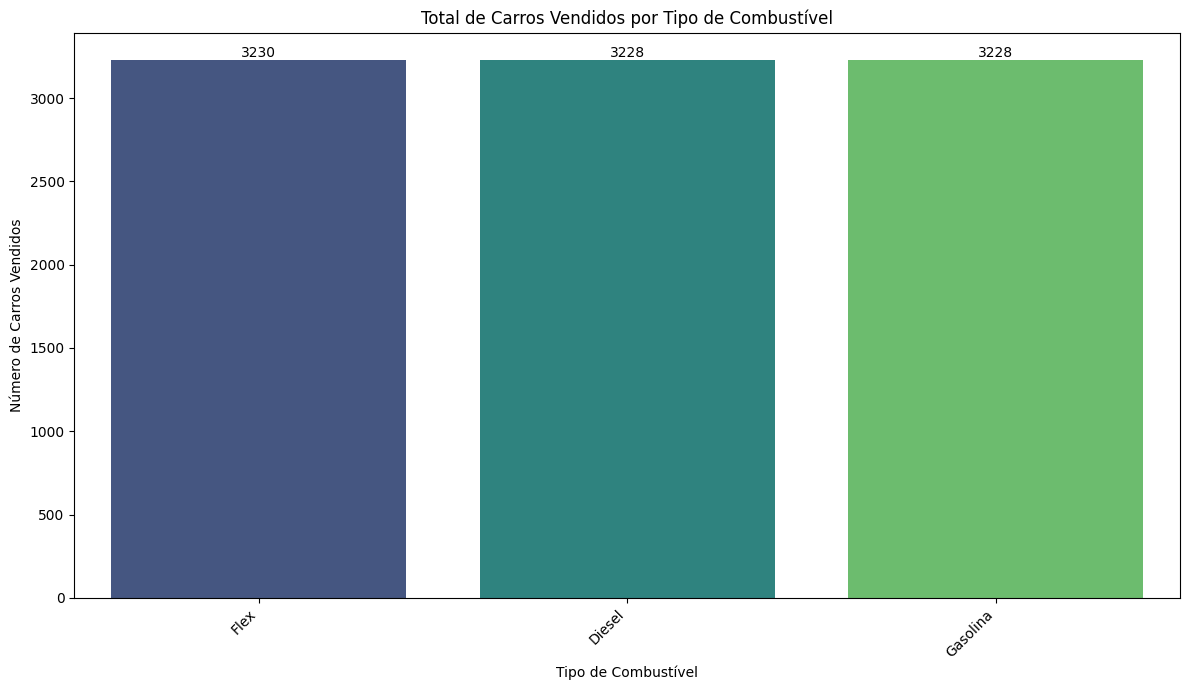

In [ ]:
fuel_type_counts = df['Combustivel'].value_counts().reset_index()
fuel_type_counts.columns = ['Combustivel', 'Count']

plt.figure(figsize=(12, 7))
sns.barplot(x='Combustivel', y='Count', data=fuel_type_counts, palette='viridis')
plt.title('Total de Carros Vendidos por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Número de Carros Vendidos')
plt.xticks(rotation=45, ha='right')

# Adicionar os valores acima das barras
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d')

plt.tight_layout()
plt.savefig(f'Total_carros_por_comb.png')
plt.show()

### Valor Médio de Venda por Cor de Carro

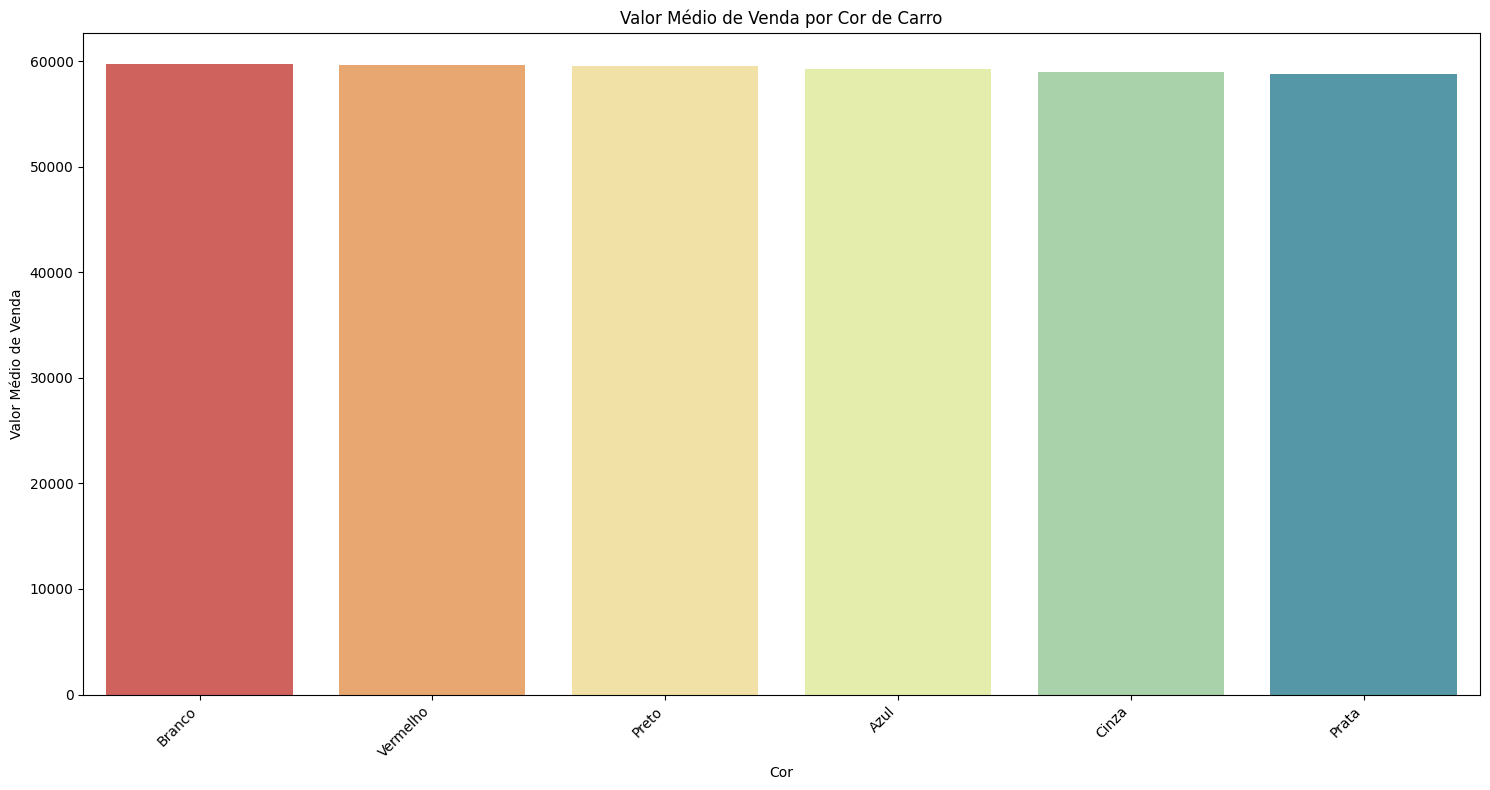

In [ ]:
valor_medio_cor = df.groupby('Cor')['Valor_Venda'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x='Cor', y='Valor_Venda', data=valor_medio_cor, palette='Spectral')
plt.title('Valor Médio de Venda por Cor de Carro')
plt.xlabel('Cor')
plt.ylabel('Valor Médio de Venda')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'Valor_medio_por_cor.png')
plt.show()

### Criar e analisar a idade do carro

In [ ]:
hoje = dt.datetime.now()
ano_atual = hoje.year
df['idade_carro'] = ano_atual - df['Ano']
df.sort_values(by='idade_carro', ascending=False, inplace=True)

In [ ]:
df

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda,idade_carro
9998,Nissan,Versa,2000,191101,Cinza,Manual,Flex,2,31730.8,26
9970,Volkswagen,T-Cross,2000,96275,Azul,Automático,Diesel,2,33033.0,26
7728,Jeep,Renegade,2000,160284,Prata,Automático,Diesel,2,62566.2,26
3694,Ford,EcoSport,2000,141295,Azul,Automático,Diesel,2,27996.0,26
3727,Volkswagen,T-Cross,2000,38554,Cinza,Automático,Flex,2,42639.2,26
...,...,...,...,...,...,...,...,...,...,...
6157,Toyota,Corolla,2023,95608,Cinza,Manual,Flex,4,98831.4,3
6199,Ford,EcoSport,2023,140240,Vermelho,Manual,Gasolina,4,64399.0,3
67,Jeep,Compass,2023,113216,Prata,Manual,Diesel,2,103841.8,3
6183,Jeep,Renegade,2023,125200,Azul,Automático,Diesel,2,103479.0,3


### Analisar distribuição da vendas de carros por idade do carro

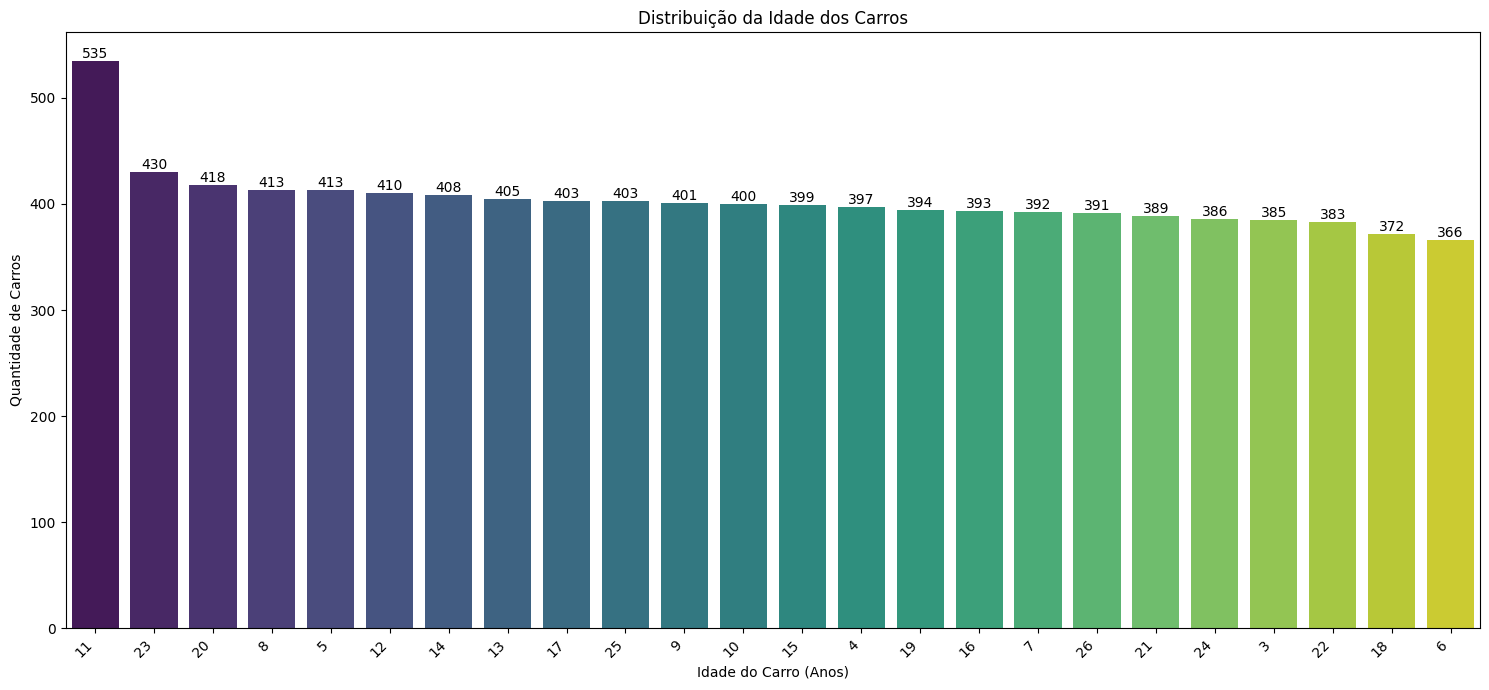

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='idade_carro', order=df['idade_carro'].value_counts().index, palette='viridis')
plt.title('Distribuição da Idade dos Carros')
plt.xlabel('Idade do Carro (Anos)')
plt.ylabel('Quantidade de Carros')
plt.xticks(rotation=45, ha='right')

# Adicionar os valores acima das barras
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d')

plt.tight_layout()
plt.savefig(f'Distribuicao_idade_carro.png')
plt.show()

### Analisar o valor médio de venda por idade do carro

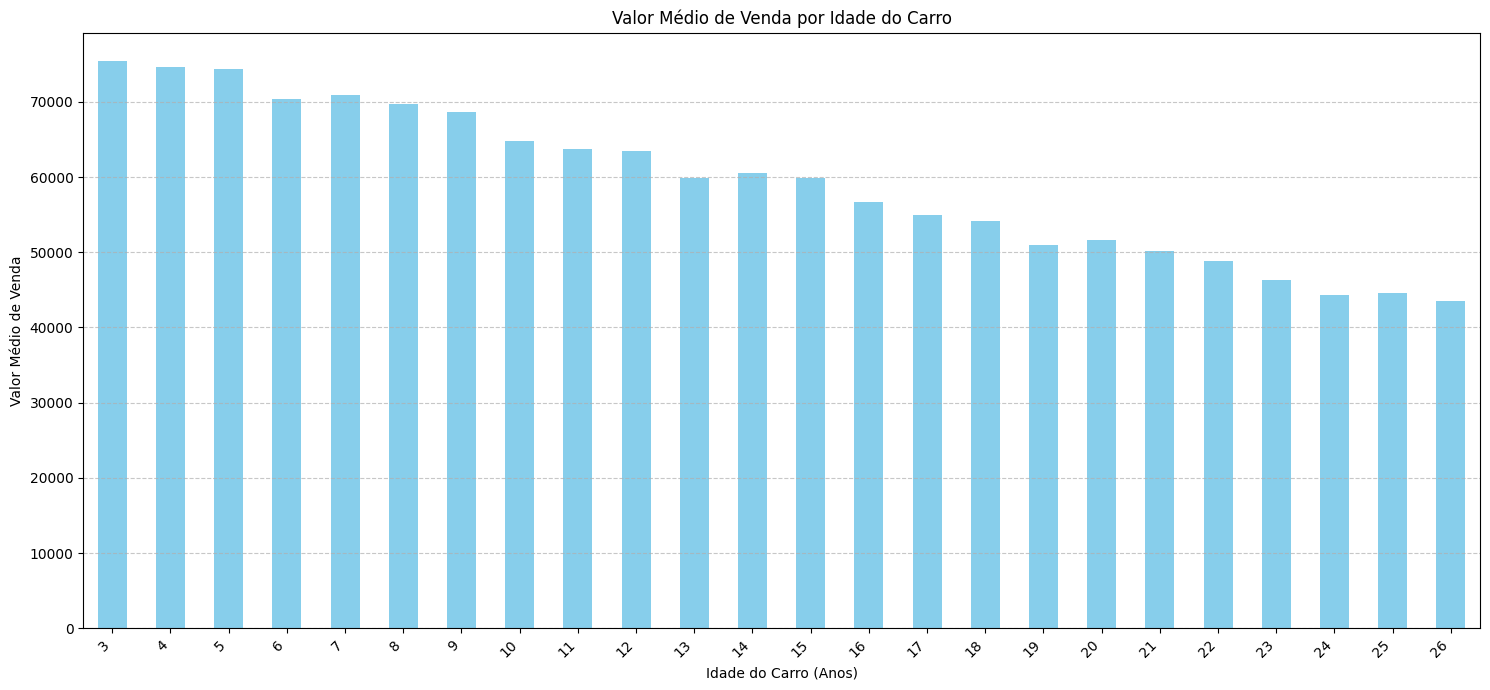

In [ ]:
plt.figure(figsize=(15, 7))
df.groupby('idade_carro')['Valor_Venda'].mean().plot(kind='bar', color='skyblue')
plt.title('Valor Médio de Venda por Idade do Carro')
plt.xlabel('Idade do Carro (Anos)')
plt.ylabel('Valor Médio de Venda')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'Valor_medio_por_idade_carro.png')
plt.show()

### Analisar valor médio de venda por idade do carro e marca com intervalo de 95%

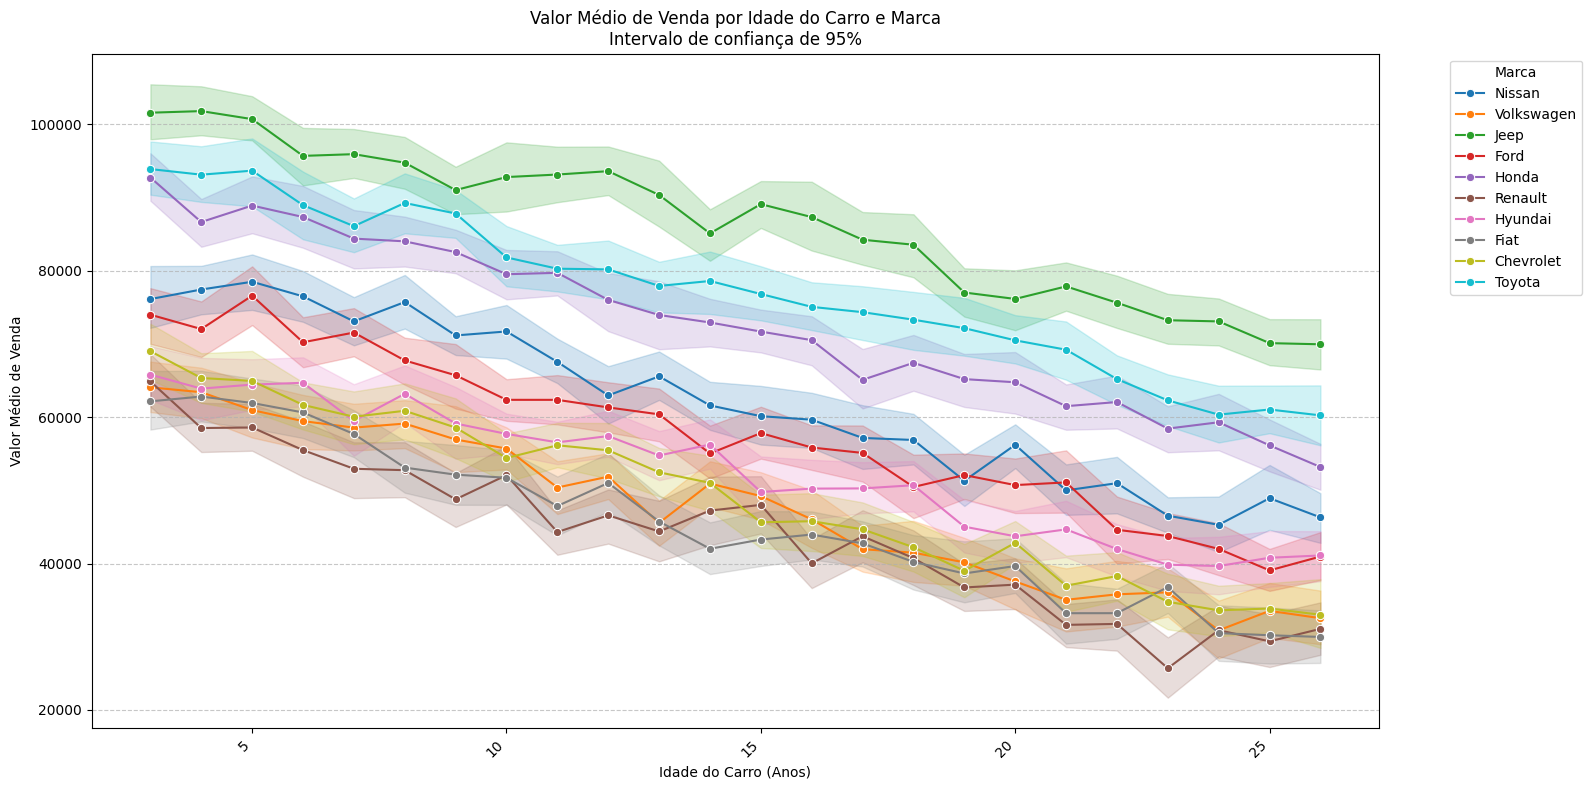

In [ ]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x='idade_carro', y='Valor_Venda', hue='Marca', marker='o')
plt.title('Valor Médio de Venda por Idade do Carro e Marca\nIntervalo de confiança de 95%')
plt.xlabel('Idade do Carro (Anos)')
plt.ylabel('Valor Médio de Venda')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'Valor_medio_por_idade_carro_marca_95.png')
plt.show()

### Analisar valor médio de venda por idade do carro e marca com intervalo de 95% (interativo)

In [ ]:
import plotly.express as px

# Agrupar os dados para calcular o valor médio de venda por idade do carro e marca
df_grouped_interactive = df.groupby(['idade_carro', 'Marca'])['Valor_Venda'].mean().reset_index()

# Criar o gráfico de linha interativo
fig = px.line(
    df_grouped_interactive,
    x='idade_carro',
    y='Valor_Venda',
    color='Marca',
    title='Valor Médio de Venda por Idade do Carro e Marca (Interativo)',
    labels={
        'idade_carro': 'Idade do Carro (Anos)',
        'Valor_Venda': 'Valor Médio de Venda'
    },
    hover_data={'Marca': True, 'idade_carro': True, 'Valor_Venda': ':.2f'}
)

fig.update_layout(xaxis_title='Idade do Carro (Anos)', yaxis_title='Valor Médio de Venda')

fig.show()

### Salvar o dataset tratado.

In [ ]:
df.head()

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda,idade_carro
9998,Nissan,Versa,2000,191101,Cinza,Manual,Flex,2,31730.8,26
9970,Volkswagen,T-Cross,2000,96275,Azul,Automático,Diesel,2,33033.0,26
7728,Jeep,Renegade,2000,160284,Prata,Automático,Diesel,2,62566.2,26
3694,Ford,EcoSport,2000,141295,Azul,Automático,Diesel,2,27996.0,26
3727,Volkswagen,T-Cross,2000,38554,Cinza,Automático,Flex,2,42639.2,26


In [ ]:
df.to_csv('dataset_final.csv', index=False)